In [1]:
# Define the default font sizes to make the figures prettier:
import matplotlib.pyplot as plt
from scipy import signal
import numpy as np
from scipy import signal
plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)

In [2]:
from pathlib import Path
IMAGES_PATH = Path() / "images" / "lms"
IMAGES_PATH.mkdir(parents=True, exist_ok=True)

def save_fig(fig_id, tight_layout=True, fig_extension="png", resolution=450):
    path = IMAGES_PATH / f"{fig_id}.{fig_extension}"
    if tight_layout:
        plt.tight_layout()
    plt.savefig(path, format=fig_extension, dpi=resolution, bbox_inches='tight')

#### Problem 7.10

Consider an $\mathbf{AR~process}~u(n)$ defined by the $\mathbf{difference~equation}$
$$
u(n) = -a_1 u(n - 1) - a_2 u(n - 2) + \nu(n),
$$
where $\nu(n)$ is an additive $\mathbf{white~noise}$ of zero mean and $\mathbf{variance}~\sigma_{\nu}^2$. The $\mathbf{AR~parameters}~a_1$ and $a_2$ are both real valued:
$$
a_1 = 0.1; \quad a_2 = -0.8.
$$

Calculate the noise variance $\sigma_{\nu}^2$ such that the AR process $u(n)$ has unit variance. Hence, generate different realizations of the process $u(n)$.

Given the input $u(n)$, in prob 6.17 an LMS algorithm of length $M=2$ is used to estimate the unknown AR parameters $a_1$ and $a_2$. The step-size parameter $\mu$ is assigned the value $0.05$. 

   * (a) Plot the learning curve  of the  normalized LMS algorithm used to estimate the AR parameters $a_1$ and $a_2$. In this computation, use the following parameters: $\tilde{\mu} = 0.2$ and $\delta = 0.5$. For the plot, average the squared error signal $e(n)$ over an ensemble of 100 independent Monte Carlo runs of the experiment.

   *  (b) Plot the corresponding errors in tap-weight estimates.

   *  (c) Repeat the plots in parts (a) and (b) for the  regularizing parameter $\delta = 0.25, 0.75$. What observation can you make on the effect of varying $\delta$?

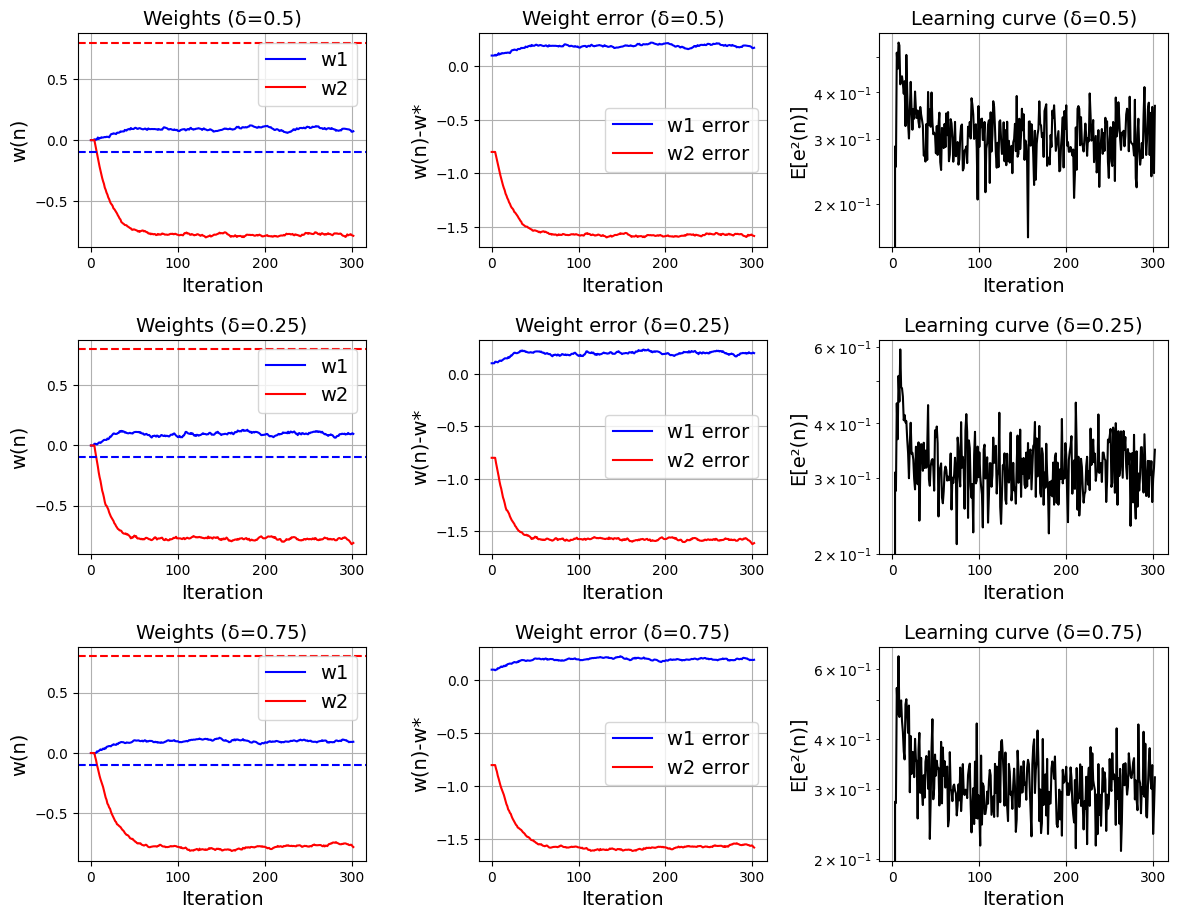

In [11]:
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------------------------------------
# Problem parameters
# -------------------------------------------------------------
N_sample    = 300
N_ensemble  = 100
a1          = 0.1
a2          = -0.8
mu          = 0.2               # NLMS step size
var_v       = 0.28
std_v       = np.sqrt(var_v)
rng         = np.random.default_rng(30)
N_init      = 3
deltas      = [0.5, 0.25, 0.75]

N_total     = N_sample + N_init

# True optimal weights
w_opt = np.array([-a1, -a2])

# -------------------------------------------------------------
# Allocate accumulators
# -------------------------------------------------------------
mse_accum    = np.zeros((len(deltas), N_total))
w1err_hist   = np.zeros((len(deltas), N_total))
w2err_hist   = np.zeros((len(deltas), N_total))
w1_hist      = np.zeros((len(deltas), N_total))
w2_hist      = np.zeros((len(deltas), N_total))

# -------------------------------------------------------------
# Monte Carlo simulation
# -------------------------------------------------------------
for i, delta in enumerate(deltas):
    for mc in range(N_ensemble):

        u = np.zeros(N_total)
        e = np.zeros(N_total)
        W = np.zeros((2, N_total))

        for n in range(N_init, N_total):

            # AR(2) process
            u[n] = a1*u[n-1] + a2*u[n-2] + rng.normal(0, std_v)

            # NLMS prediction error
            x = np.array([u[n-1], u[n-2]])
            y = W[:, n-1] @ x
            e[n] = u[n] - y

            # NLMS update
            norm2_x = x @ x
            W[:, n] = W[:, n-1] + (mu / (delta + norm2_x)) * e[n] * x

        # Accumulate over ensemble
        mse_accum[i]    += e**2
        w1err_hist[i]   += (W[0] - w_opt[0])
        w2err_hist[i]   += (W[1] - w_opt[1])
        w1_hist[i]      += W[0]
        w2_hist[i]      += W[1]

# Average
mse_avg    = mse_accum / N_ensemble
w1err_avg  = w1err_hist / N_ensemble
w2err_avg  = w2err_hist / N_ensemble
w1_avg     = w1_hist / N_ensemble
w2_avg     = w2_hist / N_ensemble

# -------------------------------------------------------------
# 4 x 3 plot: weight trajectories, weight errors, learning curves
# -------------------------------------------------------------
plt.figure(figsize=(12, 12))

for i, delta in enumerate(deltas):

    row = i

    # (1) Weight trajectories
    plt.subplot(4, 3, row*3 + 1)
    plt.plot(w1_avg[i], 'b', label='w1')
    plt.plot(w2_avg[i], 'r', label='w2')
    plt.axhline(w_opt[0], color='b', linestyle='--')
    plt.axhline(w_opt[1], color='r', linestyle='--')
    plt.title(f"Weights (δ={delta})")
    plt.xlabel("Iteration")
    plt.ylabel("w(n)")
    plt.grid(True)
    plt.legend()

    # (2) Weight errors
    plt.subplot(4, 3, row*3 + 2)
    plt.plot(w1err_avg[i], 'b', label='w1 error')
    plt.plot(w2err_avg[i], 'r', label='w2 error')
    plt.title(f"Weight error (δ={delta})")
    plt.xlabel("Iteration")
    plt.ylabel("w(n)-w*")
    plt.grid(True)
    plt.legend()

    # (3) Learning curve (log scale)
    plt.subplot(4, 3, row*3 + 3)
    plt.semilogy(mse_avg[i], 'k')
    plt.title(f"Learning curve (δ={delta})")
    plt.xlabel("Iteration")
    plt.ylabel("E[e²(n)]")
    plt.grid(True)

plt.tight_layout()
plt.show()
